<a href="https://colab.research.google.com/github/vdadithya2002/Ancient-Telugu-Character-Recognition/blob/main/RecognitionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================================
# TELUGU ALPHABET RECOGNITION HYBRID MODEL
# CNN + BiLSTM + Transformer Encoder
# ===============================================

!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!pip install tensorflow matplotlib opencv-python
import tensorflow as tf
# import tensorflow_addons as tfa # tensorflow-addons is deprecated and not compatible with Python 3.12
from tensorflow.keras import layers, models
import numpy as np
import os, cv2
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/processed_alphabets"

TRAIN_DIR = f"{DATASET_ROOT}/train"
VAL_DIR   = f"{DATASET_ROOT}/val"
TEST_DIR  = f"{DATASET_ROOT}/test"


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 40


In [ ]:
def load_dataset(folder):
    images = []
    labels = []

    for cls in classes:
        cls_dir = os.path.join(folder, cls)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0
            images.append(img)
            labels.append(class_to_idx[cls])

    images = np.array(images).reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)
    labels = np.array(labels)
    return images, labels


In [ ]:
# Define classes and their mappings based on the training directory structure
classes = sorted(os.listdir(TRAIN_DIR))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_class = {i: cls_name for i, cls_name in enumerate(classes)}
num_classes = len(classes)

X_train, y_train = load_dataset(TRAIN_DIR)
X_val, y_val     = load_dataset(VAL_DIR)
X_test, y_test   = load_dataset(TEST_DIR)

print(X_train.shape, X_val.shape, X_test.shape)


(7655, 128, 128, 1) (1304, 128, 128, 1) (1378, 128, 128, 1)


In [ ]:
def transformer_encoder(inputs, num_heads=4, key_dim=64, ff_dim=256, dropout=0.1):
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization()(inputs + x)

    f = layers.Dense(ff_dim, activation='relu')(x)
    f = layers.Dense(inputs.shape[-1])(f)

    return layers.LayerNormalization()(x + f)


In [ ]:
def build_hybrid_model():
    inputs = layers.Input(shape=(128, 128, 1))

    # CNN Feature Extractor
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    # Flatten spatial dimensions → sequence
    seq = layers.Reshape((16*16, 128))(x) # Changed from 32*32 to 16*16

    # BiLSTM branch
    lstm_out = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(seq)

    # Transformer Encoder
    trans_out = transformer_encoder(lstm_out)

    # Global sequence pooling
    pooled = layers.GlobalAveragePooling1D()(trans_out)

    # Classification Head
    out = layers.Dense(num_classes, activation="softmax")(pooled)

    model = models.Model(inputs, out)
    return model

In [ ]:
model = build_hybrid_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 256, 128)  │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256, 256)  │    263,168 │ reshape_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256)  │          0 │ bidirectional[0]… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256, 256)  │     65,792 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256, 256)  │     65,792 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 764,723 (2.92 MB)

 Trainable params: 764,723 (2.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 663s 3s/step - accuracy: 0.0191 - loss: 4.0859 - val_accuracy: 0.0383 - val_loss: 3.9130
Epoch 2/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 650s 3s/step - accuracy: 0.0368 - loss: 3.8538 - val_accuracy: 0.0567 - val_loss: 3.7113
Epoch 3/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 667s 3s/step - accuracy: 0.0627 - loss: 3.6223 - val_accuracy: 0.0652 - val_loss: 3.5845
Epoch 4/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 636s 3s/step - accuracy: 0.0795 - loss: 3.5381 - val_accuracy: 0.0874 - val_loss: 3.5176
Epoch 5/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 685s 3s/step - accuracy: 0.0979 - loss: 3.4243 - val_accuracy: 0.1058 - val_loss: 3.4125
Epoch 6/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 691s 3s/step - accuracy: 0.1285 - loss: 3.2956 - val_accuracy: 0.1273 - val_loss: 3.3442
Epoch 7/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 648s 3s/step - accuracy: 0.1567 - loss: 3.1832 - val_accuracy: 0.1281 - val_loss: 3.3350
Epoch 8/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 678s 3s/step - accuracy: 0.1741 - loss: 3.0927 - val_accu

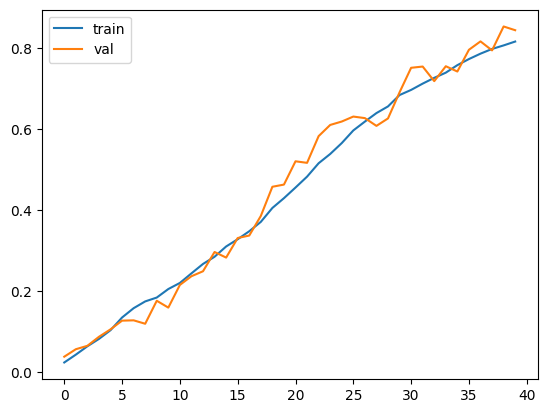

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(); plt.show()


In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


44/44 ━━━━━━━━━━━━━━━━━━━━ 34s 756ms/step - accuracy: 0.8663 - loss: 0.4728
Test Accuracy: 0.862844705581665


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os # Import os for directory operations

# Re-define DATASET_ROOT and TRAIN_DIR to ensure they are in scope for this cell
DATASET_ROOT = "/content/drive/MyDrive/processed_alphabets"
TRAIN_DIR = f"{DATASET_ROOT}/train"

# Check if the TRAIN_DIR exists
if not os.path.isdir(TRAIN_DIR):
    raise FileNotFoundError(
        f"The training directory '{TRAIN_DIR}' was not found. "
        "Please ensure your Google Drive is mounted correctly and "
        "that the 'processed_alphabets/train' folder exists at the specified path."
        "If the folder is there, try remounting your Google Drive by executing the cell: bamXoWMOR7IC"
    )

classes = sorted(os.listdir(TRAIN_DIR))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_class = {i: cls_name for i, cls_name in enumerate(classes)}
num_classes = len(classes)

def transformer_encoder(inputs, num_heads=4, key_dim=64, ff_dim=256, dropout=0.1):
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization()(inputs + x)

    f = layers.Dense(ff_dim, activation='relu')(x)
    f = layers.Dense(inputs.shape[-1])(f)

    return layers.LayerNormalization()(x + f)

def build_hybrid_model():
    inputs = layers.Input(shape=(128, 128, 1))

    # CNN Feature Extractor
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    # Flatten spatial dimensions → sequence
    seq = layers.Reshape((16*16, 128))(x)

    # BiLSTM branch
    lstm_out = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(seq)

    # Transformer Encoder
    trans_out = transformer_encoder(lstm_out)

    # Global sequence pooling
    pooled = layers.GlobalAveragePooling1D()(trans_out)

    # Classification Head
    out = layers.Dense(num_classes, activation="softmax")(pooled)

    model = models.Model(inputs, out)
    return model

# First, recreate the model architecture using the build_hybrid_model function.
# This ensures the model graph is correctly constructed with the functional transformer_encoder.
model = build_hybrid_model()

# Then, load only the weights from the saved HDF5 file into the newly created model.
# This bypasses the full model deserialization which was causing the TypeError.
model.load_weights("/content/telugu_hybrid_model.h5")

# Re-compile the model after loading weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import cv2
import numpy as np
def predict_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return "Error: Could not load image at path: " + path, 0.0
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    img = img.reshape(1,128,128,1)

    pred = model.predict(img)
    confidence = np.max(pred) # Get the maximum probability as confidence
    cls = idx_to_class[np.argmax(pred)]
    return cls, confidence

Let's evaluate the model's performance on its own training set. This will give us an idea of how well the model has learned the patterns in the data it was trained on.

In [ ]:


X_train, y_train = load_dataset(TRAIN_DIR)

# Evaluate the model on the training data
train_loss, train_acc = model.evaluate(X_train, y_train)
print("Train Accuracy:", train_acc)

240/240 ━━━━━━━━━━━━━━━━━━━━ 217s 900ms/step - accuracy: 0.8515 - loss: 0.5006
Train Accuracy: 0.8595688939094543


44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 845ms/step

Classification Report:
              precision    recall  f1-score   support

           a       0.84      0.93      0.88        45
          aa       0.89      0.93      0.91        45
          ah       1.00      0.50      0.67        18
          ai       1.00      1.00      1.00        18
          am       0.67      1.00      0.80        18
          au       0.88      1.00      0.94        15
          ba       1.00      1.00      1.00        48
         bha       0.95      0.93      0.94        42
         cha       0.92      0.53      0.68        45
        chha       0.92      0.80      0.86        30
          da       0.73      0.79      0.76        42
         dda       0.88      0.47      0.61        30
        ddha       1.00      0.93      0.96        28
         dha       0.83      0.77      0.80        26
           e       1.00      1.00      1.00        16
          ee       0.59      1.00      0.74        26
          ga   

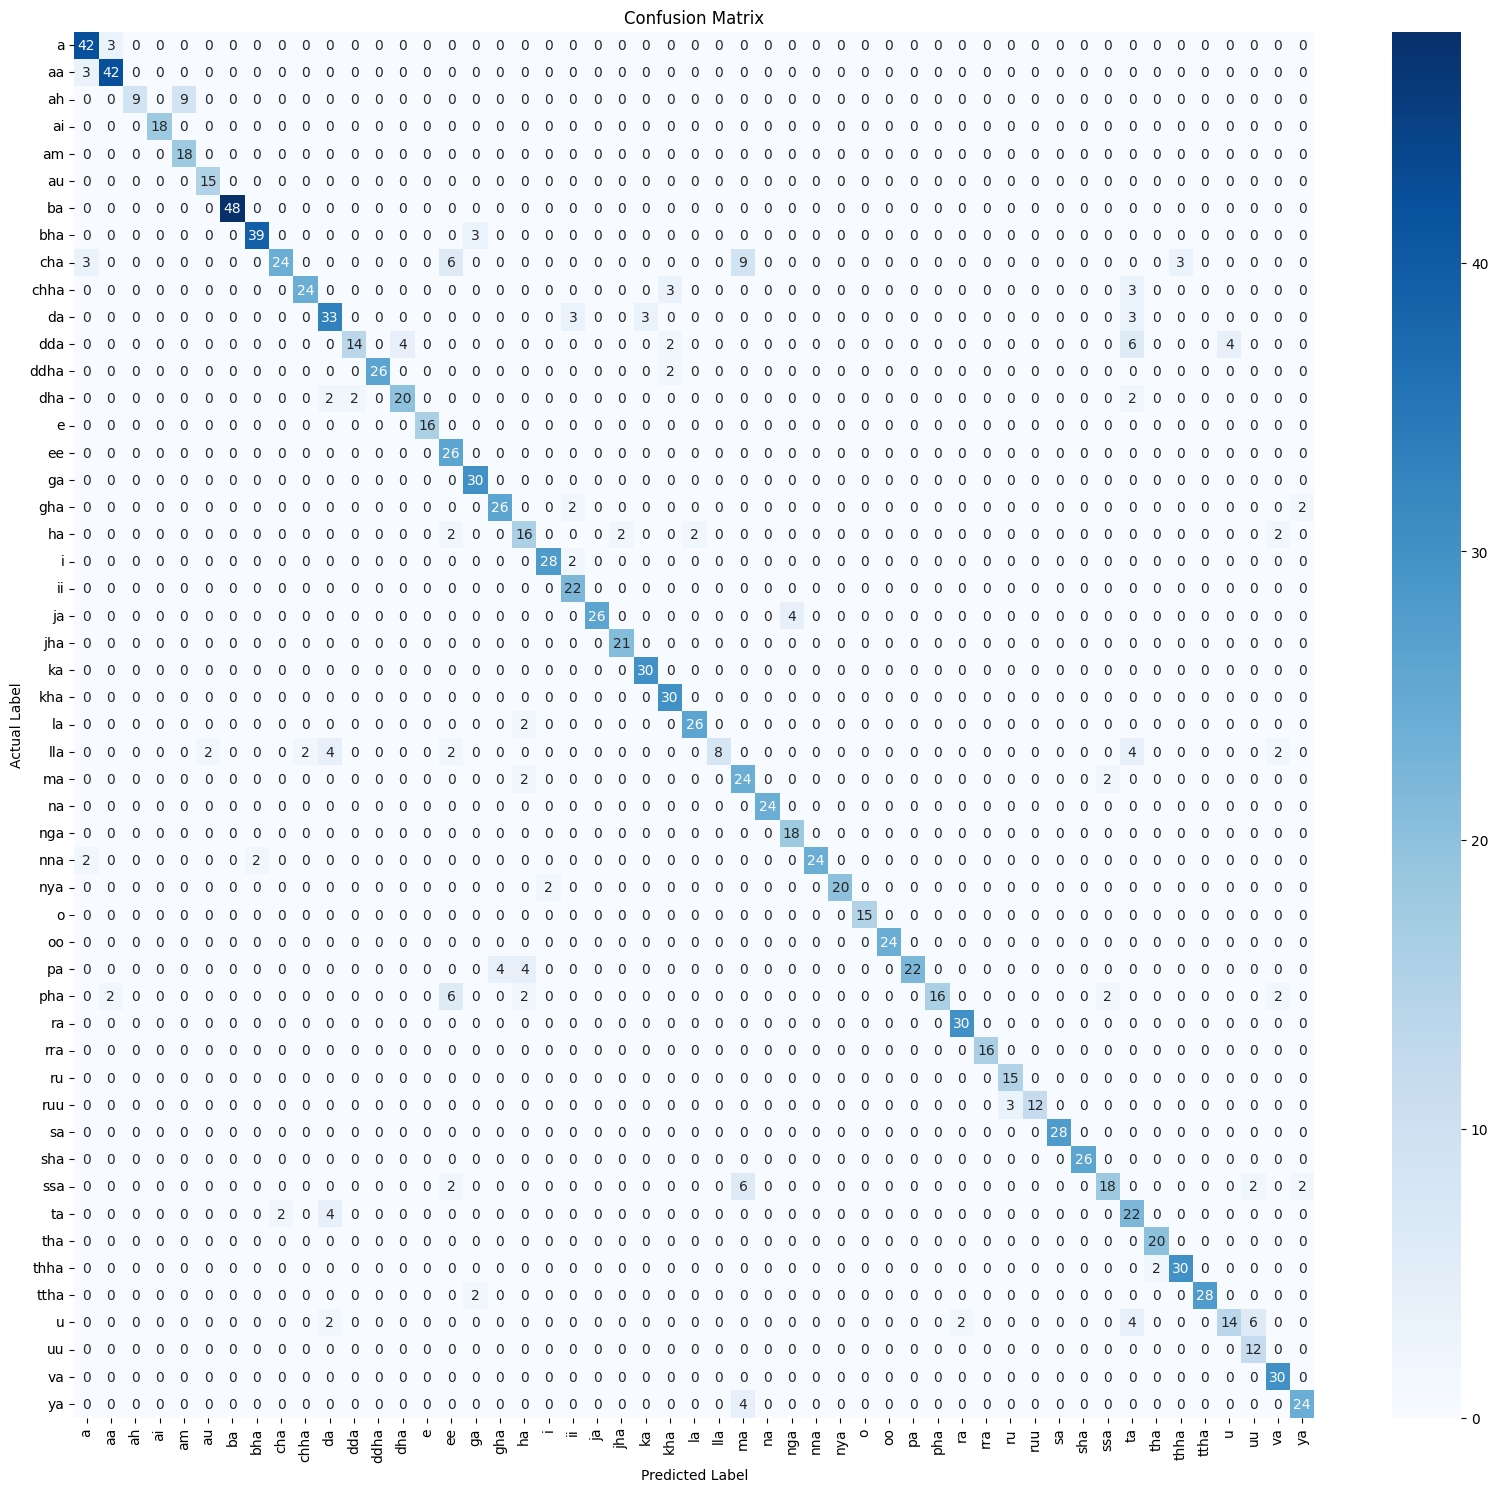

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2

# Ensure DATASET_ROOT, VAL_DIR, TEST_DIR are defined
DATASET_ROOT = "/content/drive/MyDrive/processed_alphabets"
VAL_DIR   = f"{DATASET_ROOT}/val"
TEST_DIR  = f"{DATASET_ROOT}/test"

# Ensure IMG_SIZE is defined
IMG_SIZE = (128, 128)

# Ensure load_dataset function is defined (copied from cell z1gomLfwS56R)
def load_dataset(folder):
    images = []
    labels = []

    for cls in classes: # 'classes' is expected to be in global scope from rj12HoWpjXec
        cls_dir = os.path.join(folder, cls)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0
            images.append(img)
            labels.append(class_to_idx[cls]) # 'class_to_idx' is expected to be in global scope from rj12HoWpjXec

    images = np.array(images).reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)
    labels = np.array(labels)
    return images, labels

# Load X_test and y_test
X_test, y_test = load_dataset(TEST_DIR)

# Get predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

##Prediction testing

In [ ]:
IMG_SIZE = (128, 128)
test_img = "/test_4.png"
predicted_class, confidence = predict_image(test_img)
print(f"Prediction: {predicted_class}, Confidence: {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Prediction: ruu, Confidence: 0.9904


## Calculate Character Error Rate



In [ ]:
loss, acc = model.evaluate(X_test, y_test)
cer = 1.0 - acc
print(f"Character Error Rate (CER): {cer:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 868ms/step - accuracy: 0.8692 - loss: 0.4702
Character Error Rate (CER): 0.1372
